# Chapter 2 — Fundamental Concepts: How Do Machines Learn?

**Grokking Deep Learning — Andrew W. Trask**

Notebook ini membahas konsep fundamental pada Chapter 2. Fokusnya adalah memahami bagaimana Machine Learning dibedakan berdasarkan jenis pola yang dipelajari dan bagaimana hasil pembelajaran direpresentasikan.

> **Catatan:** Chapter 2 masih bersifat konseptual, sehingga notebook ini tidak memaksakan pembangunan model atau code yang belum menjadi fokus chapter.

## Learning Objectives

Setelah mempelajari chapter ini, kita diharapkan mampu:

- menjelaskan hubungan **Artificial Intelligence, Machine Learning, dan Deep Learning**;
- membedakan **Supervised Learning** dan **Unsupervised Learning**;
- memahami perbedaan **Parametric** dan **Nonparametric Learning**;
- memahami empat kombinasi pendekatan Machine Learning;
- menjelaskan paradigma **PREDICT → COMPARE → LEARN** yang menjadi dasar chapter berikutnya.

## Chapter Roadmap

Chapter 2 membangun vocabulary dan mental model dasar sebelum mulai membuat neural network.

1. **What is Deep Learning?**
2. **What is Machine Learning?**
3. **Supervised Machine Learning**
4. **Unsupervised Machine Learning**
5. **Parametric vs. Nonparametric Learning**
6. **Supervised Parametric Learning**
7. **Unsupervised Parametric Learning**
8. **Nonparametric Learning**
9. **Summary**

Chapter ini menjadi jembatan dari pengenalan Deep Learning menuju implementasi neural network pada Chapter 3.

## 1. What is Deep Learning?

**Deep Learning** merupakan subset dari **Machine Learning**. Bidang ini menggunakan metode Machine Learning, terutama **Artificial Neural Networks**, untuk mempelajari pola dari data.

Dalam konteks industri, Deep Learning dapat digunakan untuk tugas seperti:

- **Computer Vision** → image;
- **Natural Language Processing** → text;
- **Automatic Speech Recognition** → audio.

Deep Learning tidak harus selalu dikaitkan dengan tujuan menciptakan *general artificial intelligence*. Banyak penerapannya digunakan untuk menyelesaikan masalah praktis tertentu.

**Inti konsep:**

> Artificial Intelligence ⟶ Machine Learning ⟶ Deep Learning

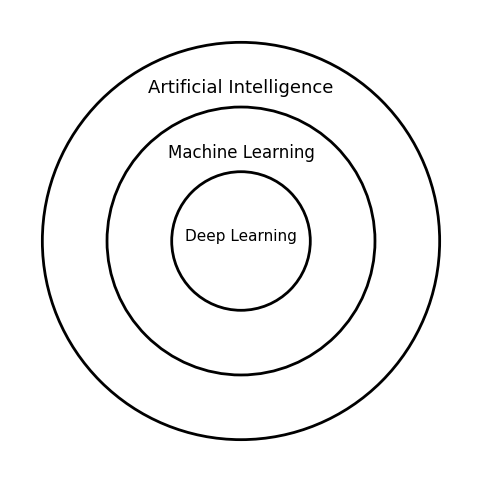

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(9, 6))

for radius in (0.43, 0.29, 0.15):
    ax.add_patch(Circle((0.5, 0.5), radius, fill=False, linewidth=2))

ax.text(0.5, 0.82, "Artificial Intelligence", ha="center", fontsize=13)
ax.text(0.5, 0.68, "Machine Learning", ha="center", fontsize=12)
ax.text(0.5, 0.50, "Deep Learning", ha="center", fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

**Interpretasi diagram:** diagram ini merupakan ilustrasi konseptual hubungan *subset* yang dibahas pada chapter: **Machine Learning** berada dalam cakupan **Artificial Intelligence**, sedangkan **Deep Learning** merupakan bagian dari **Machine Learning**.

## 2. What is Machine Learning?

Secara umum, **Machine Learning** adalah bidang yang membuat komputer mampu belajar melakukan suatu tugas tanpa seluruh aturan untuk tugas tersebut harus diprogram secara eksplisit.

Ide sederhananya:

> Mesin mengamati pola pada data dan berusaha menirukan atau memanfaatkannya untuk menghasilkan output.

Chapter ini kemudian membagi Machine Learning berdasarkan jenis pola yang dipelajari:

- **Supervised Learning**
- **Unsupervised Learning**

## 3. Supervised Machine Learning

Pada **Supervised Learning**, model belajar dari hubungan antara input dan output yang menjadi target pembelajaran.

Secara sederhana:

**Input Dataset → Machine Learning → Output Dataset**

Model mencoba mempelajari pola sehingga ketika diberikan input yang serupa, model dapat menghasilkan prediksi yang sesuai.

Contoh konseptual dalam buku adalah memprediksi kemungkinan sebuah tim memenangkan pertandingan berdasarkan informasi seperti lokasi pertandingan, lawan, jumlah pemain, dan jumlah fans.

Hal pentingnya adalah terdapat **pattern/truth** yang dapat digunakan untuk membandingkan hasil prediksi.

## 4. Unsupervised Machine Learning

Berbeda dengan Supervised Learning, **Unsupervised Learning** tidak diberikan *right answer* yang sudah diketahui sebelumnya.

Tujuannya adalah menemukan struktur atau pola yang terdapat di dalam data.

Salah satu contoh yang digunakan dalam chapter adalah **clustering**.

```text
Datapoints
    ↓
Unsupervised Learning
    ↓
Cluster Labels
```

Model dapat menemukan bahwa beberapa data memiliki kemiripan dan mengelompokkannya. Label cluster tersebut tidak harus memiliki nama yang sudah ditentukan sebelumnya.

**Inti konsep:**

> Supervised Learning berusaha mempelajari target yang diketahui, sedangkan Unsupervised Learning berusaha menemukan struktur dalam data.

## 5. Parametric vs. Nonparametric Learning

Pembagian berikutnya menggunakan sudut pandang yang berbeda.

**Parametric Learning** dan **Nonparametric Learning** berkaitan dengan bagaimana hasil pembelajaran direpresentasikan atau disimpan.

| Aspek | Parametric | Nonparametric |
|---|---|---|
| Jumlah parameter | Tetap | Ditentukan oleh data |
| Gambaran sederhana | Trial-and-error | Counting dan probability |
| Cara membentuk model | Mengubah parameter yang tersedia | Menggunakan struktur yang berasal dari data |
| Contoh istilah | Weights | Counts |

Chapter memberikan definisi sederhana: **Parametric model** memiliki jumlah parameter yang tetap, sedangkan **Nonparametric model** memiliki jumlah parameter yang ditentukan oleh data.

Buku juga menekankan bahwa batas antara keduanya tidak selalu benar-benar tegas.

## 6. Four Types of Machine Learning

Karena **Supervised/Unsupervised** dan **Parametric/Nonparametric** merupakan dua cara klasifikasi yang berbeda, keduanya dapat dikombinasikan.

| | **Parametric** | **Nonparametric** |
|---|---|---|
| **Supervised** | Supervised Parametric | Supervised Nonparametric |
| **Unsupervised** | Unsupervised Parametric | Unsupervised Nonparametric |

Jadi, sebuah algoritma Machine Learning dapat dipandang melalui dua pertanyaan:

1. **Apakah model mempelajari target yang diketahui?** → Supervised / Unsupervised
2. **Bagaimana parameter model direpresentasikan?** → Parametric / Nonparametric

## 7. Supervised Parametric Learning

**Supervised Parametric Learning** dapat dipahami menggunakan analogi **knobs**.

Model memiliki sejumlah parameter tetap. Data masuk ke model, model menghasilkan prediksi, kemudian parameter atau *knobs* disesuaikan agar prediksi berikutnya menjadi lebih baik.

Chapter membaginya menjadi tiga langkah:

### Step 1 — Predict
Data dimasukkan ke model untuk menghasilkan prediksi.

### Step 2 — Compare to the truth pattern
Prediksi dibandingkan dengan kondisi sebenarnya.

### Step 3 — Learn the pattern
Parameter disesuaikan berdasarkan kesalahan prediksi dan input yang digunakan.

Pola tiga langkah inilah yang berkembang menjadi:

**PREDICT → COMPARE → LEARN**

## 8. Unsupervised Parametric Learning

Pada **Unsupervised Parametric Learning**, model tetap menggunakan sejumlah parameter untuk mempelajari pengelompokan data.

Perbedaannya adalah model tidak diberikan target output yang benar seperti pada Supervised Learning.

Secara konseptual:

```text
Input Data
    ↓
Parametric Model
    ↓
Probability / Affinity
    ↓
Group / Cluster
```

Model dapat menggunakan parameter untuk menentukan seberapa kuat sebuah datapoint berhubungan dengan kelompok tertentu.

## 9. Nonparametric Learning

**Nonparametric Learning** menggunakan jumlah parameter yang bergantung pada data.

Chapter memberikan gambaran sederhana melalui pendekatan **counting**. Misalnya, sebuah model dapat menghitung seberapa sering suatu kondisi tertentu berkaitan dengan output tertentu.

Jika jumlah kategori atau pola yang perlu dihitung bertambah, jumlah parameter yang digunakan juga dapat bertambah.

Hal ini berbeda dengan Parametric Learning yang memulai proses dengan jumlah parameter yang telah ditentukan.

> Dalam konteks buku, Deep Learning termasuk kelas **Parametric Models** karena neural network menggunakan parameter seperti **weights** untuk merepresentasikan pola yang dipelajari.

## PREDICT → COMPARE → LEARN

Salah satu konsep terpenting yang diperkenalkan pada Chapter 2 adalah paradigma:

```text
┌─────────┐
│ PREDICT │
└────┬────┘
     ↓
┌─────────┐
│ COMPARE │
└────┬────┘
     ↓
┌─────────┐
│  LEARN  │
└────┬────┘
     │
     └──────────────→ kembali ke PREDICT
```

### PREDICT
Model menggunakan parameter yang dimilikinya untuk menghasilkan prediksi.

### COMPARE
Prediksi dibandingkan dengan informasi yang menjadi acuan, ketika tersedia dalam pembelajaran supervised.

### LEARN
Model menggunakan informasi tersebut untuk menyesuaikan parameter sehingga prediksi berikutnya dapat menjadi lebih baik.

Paradigma ini menjadi dasar pembahasan chapter berikutnya. **Chapter 3** mulai berfokus pada tahap **PREDICT** dan memperkenalkan neural network sederhana.

## Concept Check

**1. Apakah semua Artificial Intelligence merupakan Deep Learning?**

Tidak. Deep Learning merupakan subset dari Machine Learning, yang pada gilirannya berada dalam cakupan Artificial Intelligence.

**2. Apa perbedaan utama Supervised dan Unsupervised Learning?**

Supervised Learning mempelajari pola dengan target/output yang menjadi acuan, sedangkan Unsupervised Learning mencari struktur atau pola tanpa *right answer* yang telah ditentukan.

**3. Apa yang membedakan Parametric dan Nonparametric Learning?**

Parametric menggunakan jumlah parameter yang tetap, sedangkan Nonparametric memungkinkan jumlah parameter ditentukan oleh data.

**4. Apa tiga langkah utama yang diperkenalkan chapter ini?**

**PREDICT → COMPARE → LEARN**.

## Key Takeaways

- **Deep Learning** adalah subset dari **Machine Learning**.
- **Machine Learning** memungkinkan mesin mempelajari pola tanpa seluruh aturan harus diprogram secara eksplisit.
- **Supervised Learning** mempelajari hubungan input-output berdasarkan target yang menjadi acuan.
- **Unsupervised Learning** mencari struktur atau kelompok dalam data.
- **Parametric Learning** menggunakan jumlah parameter yang tetap.
- **Nonparametric Learning** memiliki jumlah parameter yang bergantung pada data.
- Deep Learning termasuk **Parametric Models**.
- Paradigma penting yang diperkenalkan adalah **PREDICT → COMPARE → LEARN**.
- Chapter berikutnya mulai berpindah dari konsep menuju implementasi **neural prediction**.

## Chapter Summary

Chapter 2 memberikan fondasi konseptual sebelum implementasi neural network dimulai.

Machine Learning dapat diklasifikasikan dari dua sudut pandang: **Supervised vs. Unsupervised** dan **Parametric vs. Nonparametric**. Dari kombinasi keduanya, terdapat empat kelompok pendekatan.

Chapter juga memperkenalkan cara berpikir **PREDICT → COMPARE → LEARN**. Pola ini menjadi fondasi bagi pembahasan berikutnya, ketika neural network mulai digunakan untuk membuat prediction dan kemudian dikembangkan menjadi proses learning.

Dengan demikian, tujuan utama Chapter 2 bukan membangun model, tetapi membangun **mental model dan vocabulary** yang diperlukan untuk memahami chapter-chapter selanjutnya.

## Reference

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.

**Source:** Chapter 2 — *Fundamental Concepts: How Do Machines Learn?*